# TP2 INGENIEURIE DES DONNEES
## Victor Bouvier d'Acher

*Importation des bibliothèques*

In [1]:
import  numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

### 2. Evalutation

- 1

In [2]:
base1 = np.loadtxt('base1.txt')
base1 = base1[:, :-1]

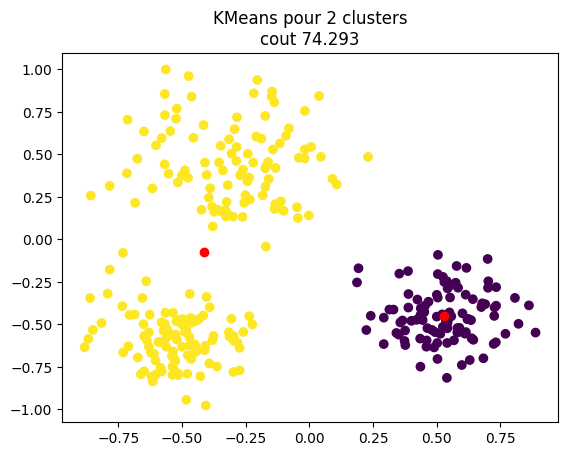

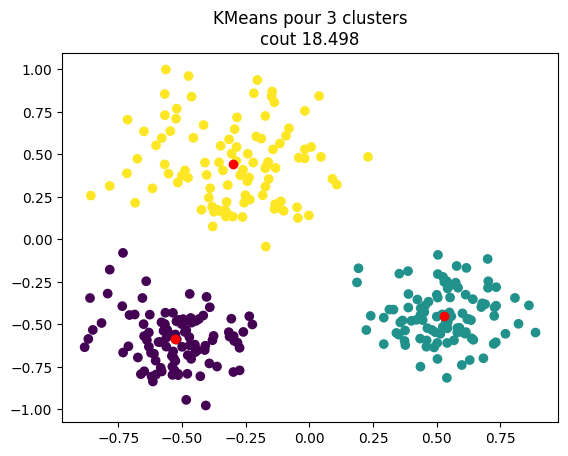

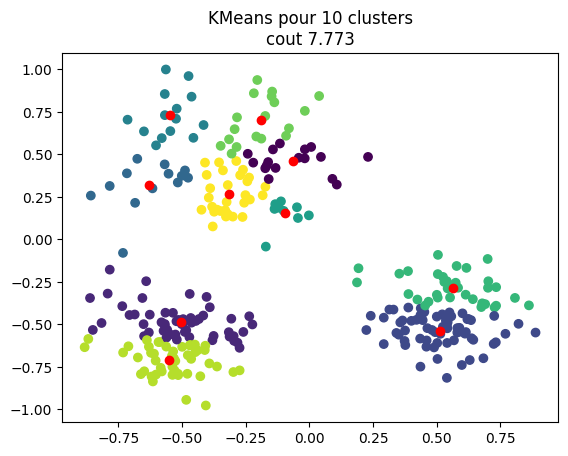

In [3]:
centre_clusters = []
label_clusters = []
cout = []

for i in range(1, 20, 1):
    repond = KMeans(n_clusters=i, n_init=1).fit(base1)
    centre_clusters.append(repond.cluster_centers_)
    label_clusters.append(repond.labels_)
    cout.append(repond.inertia_)

t = [1, 2, 9]
for i in t:
    plt.scatter(base1[:,0], base1[:,1], c=label_clusters[i])
    plt.scatter(centre_clusters[i][:,0], centre_clusters[i][:,1], marker='o', c='red')
    plt.title(f'KMeans pour {i+1} clusters\ncout {round(cout[i], 3)}')
    plt.show()


On remarque avec les graphiques que le nombre optimal de cluster est **3**.  

Valeur du coup en fonction du nombre de cluster :  

|nombre de cluster | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 |
|-                 |---|---|---|---|---|---|---|---|---|----|----|----|
|**valeur du coup**|143|75 |18 |16 |12|11.8|9.9|8.5|7.6|6.7 |6.3 |5.7 |

- 2

In [4]:
def calcul_moyen(base):
    cout_moyen = []
    var = []

    for i in range(1, 20, 1):
        couts = []
        for j in range(5):
            repond = KMeans(n_clusters=i, n_init=1).fit(base)
            couts.append(repond.inertia_)
        
        cout_moyen.append(np.mean(couts))

    for i in range(1, 20, 1):
        couts = []
        for j in range(100):
            repond = KMeans(n_clusters=i, n_init=1).fit(base)
            couts.append(repond.inertia_)
        var.append(round(np.var(couts), 3))

    ordonne = [i+1 for i in range(19)]
    plt.plot(ordonne, cout_moyen)
    plt.title('Elbow du KMeans en fonction du nombre de clusters')
    plt.show()

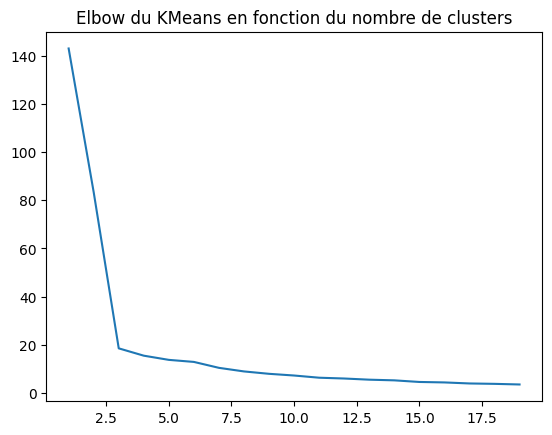

In [5]:
calcul_moyen(base1)

On constate avec la méthode du coude que la valeur optimal est **3**.  
  
Variance en fonction du nombre de cluster :  
|nombre de cluster | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 |
|-                 |---|---|---|---|---|---|---|---|---|----|----|----|
|**variance**      |0.0|38 |0.0 |0.88|0.4|0.32|0.27|0.12|0.09|0.08|0.06|0.05|

- 3

In [6]:
base3 = np.loadtxt('base3.txt')

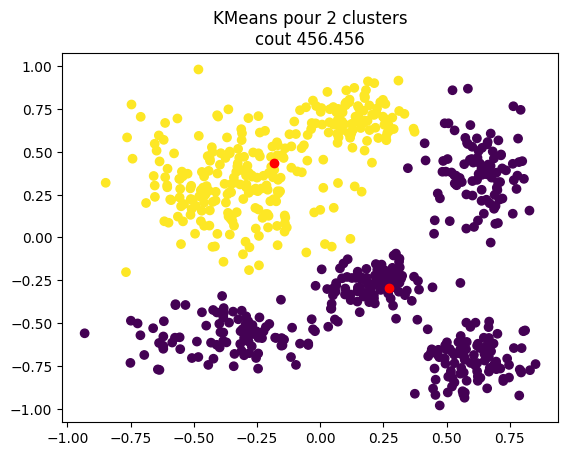

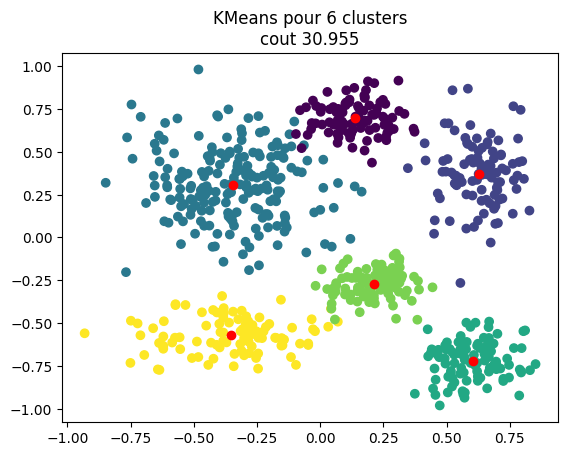

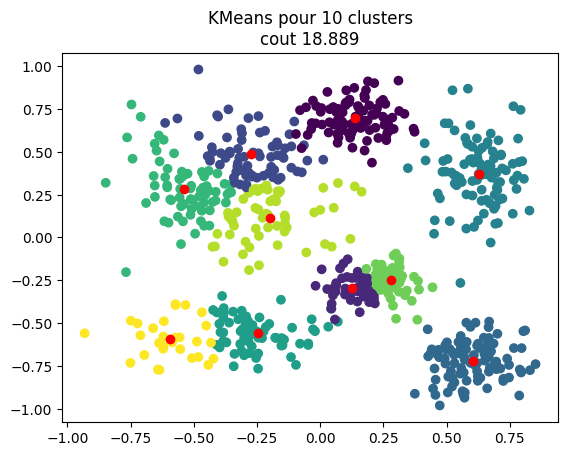

[1061.0785837928977, 456.4557863410968, 284.5541302424331, 168.42526954056618, 101.28288410547202, 30.954769535285983, 26.157168560949554, 23.5423666149375, 20.942742323004182, 18.88858857316164, 15.827306039842197, 15.628605526988668, 14.087801396907961, 13.45678450669489, 12.839031965602478, 12.090076808674027, 12.157717616362907, 11.640981483463532, 10.640199376982773]


In [7]:
cc = []
lc = []
c = []

for i in range(1, 20, 1):
    repond = KMeans(n_clusters=i, n_init=1).fit(base3)
    cc.append(repond.cluster_centers_)
    lc.append(repond.labels_)
    c.append(repond.inertia_)

t = [1, 5, 9]
for i in t:
    plt.scatter(base3[:,0], base3[:,1], c=lc[i])
    plt.scatter(cc[i][:,0], cc[i][:,1], marker='o', c='red')
    plt.title(f'KMeans pour {i+1} clusters\ncout {round(c[i], 3)}')
    plt.show()

print(c)

On remarque avec les graphiques que le nombre optimal de cluster est **6**.  

Valeur du coup en fonction du nombre de cluster :  

|nombre de cluster | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 |
|-                 |---|---|---|---|---|---|---|---|---|----|----|----|
|**valeur du coup**|1061|456|299|168|98|30.9|25.6|22.9|19.5|19.6|17.6|15|

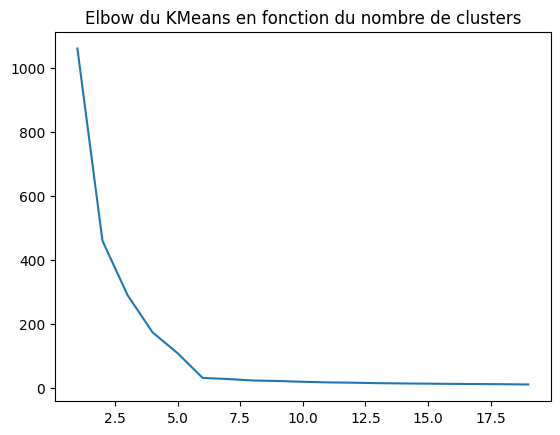

In [8]:
calcul_moyen(base3)

On constate avec la méthode du coude que la valeur optimal est **6**.  
  
Variance en fonction du nombre de cluster :  
|nombre de cluster | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 |
|-                 |---|---|---|---|---|---|---|---|---|----|----|----|
|**variance**      |0.0|19|859|452|131|0.0|2.37|1.16|1.06|1.37|0.97|0.79|

### 3. Application

- Clustering

In [9]:
digits = load_digits()

chiffre = digits.target
data = digits.data

In [10]:
X_train, X_test, y_train, y_test = train_test_split(data, chiffre, test_size=0.3)

nombre = KMeans(n_clusters=10, n_init=1).fit(X_train)

label = nombre.labels_

pure = []

for i in range(10):
    clus_i = np.where(label == i)[0]
    # print(f'clus_i : {clus_i}')
    nb = np.bincount(y_train[clus_i])
    # print(f'nb : {nb}')
    class_maj = np.argmax(nb)
    # print(f'class {class_maj}')
    clus_s = len(clus_i)
    pur = nb[class_maj] / clus_s
    pure.append(pur)
    
    print(f'Pureté du cluster {i} : {round(pur, 3)*100} %')

moy_pure = np.mean(pure)
var_pure = np.var(pure)

print(f'Pureté moyenne :  {round(moy_pure, 3) * 100}')
print(f'Variance de la pureté : {round(var_pure, 3)}')

Pureté du cluster 0 : 98.4 %
Pureté du cluster 1 : 65.60000000000001 %
Pureté du cluster 2 : 92.9 %
Pureté du cluster 3 : 97.39999999999999 %
Pureté du cluster 4 : 47.0 %
Pureté du cluster 5 : 80.30000000000001 %
Pureté du cluster 6 : 85.7 %
Pureté du cluster 7 : 98.5 %
Pureté du cluster 8 : 87.4 %
Pureté du cluster 9 : 37.5 %
Pureté moyenne :  79.10000000000001
Variance de la pureté : 0.043


In [11]:
moy_purete = []
var_purete = []
pour_purete = [[] for i in range(10)]

for i in range(100):
    X_train, X_test, y_train, y_test = train_test_split(data, chiffre, test_size=0.3)

    nombre = KMeans(n_clusters=10, n_init=1).fit(X_train)

    label = nombre.labels_

    pure = []

    for i in range(10):
        clus_i = np.where(label == i)[0]
        nb = np.bincount(y_train[clus_i])
        class_maj = np.argmax(nb)
        clus_s = len(clus_i)
        pur = nb[class_maj] / clus_s
        pure.append(pur)
        purete = pur
        pour_purete[i].append(purete)
    moy_purete.append(np.mean(pure))
    var_purete.append(np.var(pure))


|cluster | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 |
|-       |---|---|---|---|---|---|---|---|---|----|
|**pureté**|76.9|76|76.5|82|80.1|79.4|78.7|81.4|84.9|80|

Pureté moyenne = **79.6**  
Variance de la pureté = **0.035**

- Classification

In [12]:
dico = {}

for i, k in enumerate(data):
    if chiffre[i] not in dico.keys():
        dico[i] = []
    dico[chiffre[i]].append(k)


In [13]:

for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(data, chiffre, test_size=0.3)
    nombre = KMeans(n_clusters=1, n_init=1).fit(X_train)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(data, chiffre, test_size=0.3)

dico = {}

for i, k in enumerate(X_train):
    if y_train[i] not in dico.keys():
        dico[y_train[i]] = []
    dico[y_train[i]].append(k)



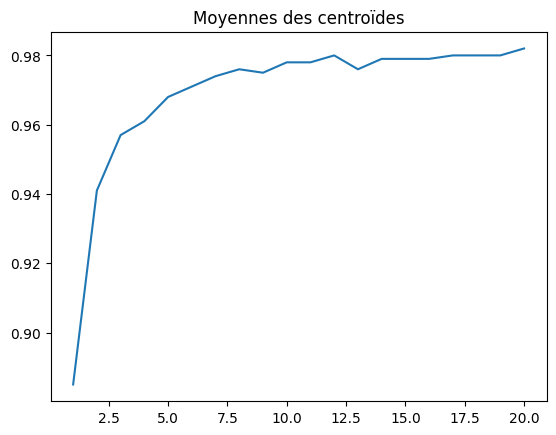

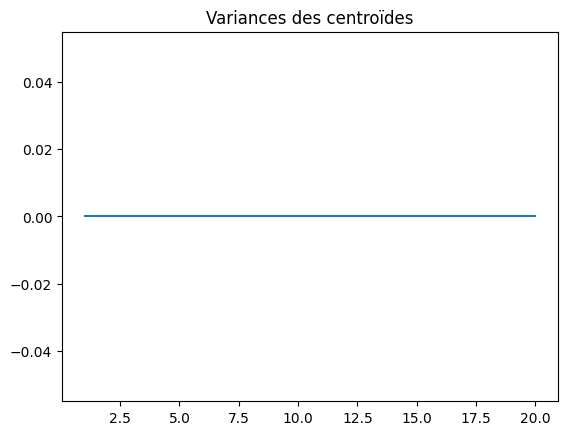

In [15]:
score = []
moyenne_fin = []
variance_fin = []

for i in range(1, 21, 1):
    clu = []
    for v in range(15):
        c = []
        classe = []
        for j in range(10):
            K = KMeans(n_clusters=i, n_init=1).fit(dico[j])
            c.extend(K.cluster_centers_)
            for k in range(i):
                classe.append(j)
        
        knn = KNeighborsClassifier(n_neighbors=1)
        knn.fit(c, classe)
        clu.append(knn.score(X_test, y_test))
    moyenne_fin.append(round(np.mean(clu), 3))
    variance_fin.append(round(np.var(clu), 3))

plt.title("Moyennes des centroïdes")
plt.plot([i+1 for i in range(20)], moyenne_fin)
plt.show()
plt.title("Variances des centroïdes")
plt.plot([i+1 for i in range(20)], variance_fin)
plt.show()

On constate que la variance est **nul**.  
La moyenne debute à **90%** mais monte rapidement à **98%-99%** au bout de **5** centroïdes.